### Qué es la vision artificial

La visión artificial (o visión por computadora) es un campo de la inteligencia artificial (IA) que dota a las computadoras y máquinas con la capacidad de procesar, analizar y comprender el mundo visual a través de imágenes y videos

### Detencción de rostros con Python usando OpenCV

In [5]:
#1. Instalación de OpenCV Library

#pip install opencv-python

import cv2

#cargar imagen

imgpath = 'images.jpg'

#4. Leer la imagen
img = cv2.imread(imgpath)

#5. Mostrar la imagen
img.shape


(678, 452, 3)

In [6]:
# 6. Convertir la imagen a escala de grises
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img.shape

(678, 452)

In [7]:
import cv2
# Cargar clasificador de rostros
cascade = "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade)

# Verificar si el clasificador cargo correctamente
if face_cascade.empty():
    print("Error: No se pudo cargar, verificar el xml")
else:
    print("Clasificador cargado correctamente")    

Clasificador cargado correctamente


In [8]:
import cv2
face = face_cascade.detectMultiScale(
    gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
)

In [9]:
for (x, y, w, h) in face:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    

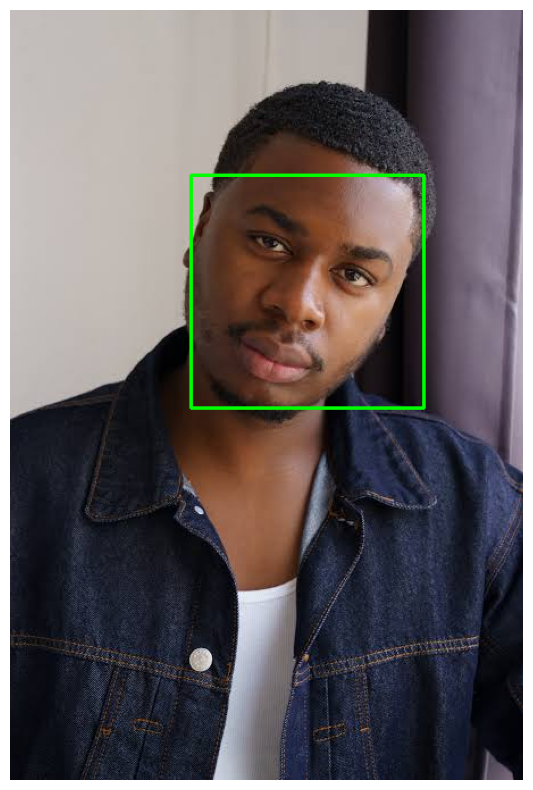

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# captura de video e tiempo real


In [11]:
video_capture = cv2.VideoCapture(0)
def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    face = face_cascade.detectMultiScale(
        gray_img, 1.1, 5, minSize=(40, 40)
    )
    for (x, y, w, h) in face:
        cv2.rectangle(vid, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return face

In [12]:
while True:
    result, video_frame = video_capture.read()
    if not result:
        break
    faces = detect_bounding_box(video_frame)
    cv2.imshow("mi cara detectada", video_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

video_capture.release()
cv2.destroyAllWindows()